# 🔍 Feature Selection — SP500 M5
## Sélection statistique des features les plus informatives

**Basé sur** : Dingli & Sant Fournier (2017) — *"rather than passing all features to our predictive model we use feature selection techniques in order to statistically identify the most relevant features"*

Ce notebook implémente exactement la méthodologie du mémoire :

1. Imports & Chargement
2. **ANOVA F-test (f_classif)** — comme le mémoire
3. **Mutual Information** — complément non-linéaire
4. **Corrélation de Pearson** — référence simple
5. **Analyse de stabilité** — les features robustes dans le temps
6. **Score combiné** — synthèse des 3 méthodes
7. **Sélection finale** — top K features
8. **Vérification multicolinéarité** — VIF
9. Export du dataset réduit

## 0. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif
)
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid')

DATA_DIR = Path('../SCR/data/processed')

# Chargement train/test (issus du notebook 02)
df_train = pd.read_csv(DATA_DIR / 'sp500_train_features.csv', index_col='time', parse_dates=True)
df_test  = pd.read_csv(DATA_DIR / 'sp500_test_features.csv',  index_col='time', parse_dates=True)

print(f'✅ Train : {len(df_train):,} obs × {df_train.shape[1]-1} features')
print(f'   Test  : {len(df_test):,} obs × {df_test.shape[1]-1} features')
print(f'   Période train : {df_train.index.min().date()} → {df_train.index.max().date()}')
print(f'   Période test  : {df_test.index.min().date()} → {df_test.index.max().date()}')

# Séparation features / label
FEATURE_COLS = [c for c in df_train.columns if c != 'label']
X_train = df_train[FEATURE_COLS].values
y_train = df_train['label'].values.astype(int)
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test['label'].values.astype(int)

print(f'\n   X_train : {X_train.shape} | y_train : {y_train.shape}')
print(f'   Classes  : Up={( y_train==1).sum():,} | Down={(y_train==0).sum():,}')

✅ Train : 49,477 obs × 106 features
   Test  : 12,368 obs × 106 features
   Période train : 2024-12-11 → 2026-01-19
   Période test  : 2026-01-19 → 2026-04-17

   X_train : (49477, 106) | y_train : (49477,)
   Classes  : Up=25,810 | Down=23,667


## 1. ANOVA F-test — `f_classif`

**Exactement comme le mémoire** (section 3.4) :
> *"One function 'f_classif' is used when the target output is a predefined class. This function makes use of the ANOVA F-test and outputs a score known as the F-Value."*

Le F-Value mesure le **ratio de variance inter-classes / intra-classes** — plus il est élevé, plus la feature sépare bien Up et Down.

=== ANOVA F-test ===
  Features significatives (p<0.05) : 27 / 106
  Features non significatives      : 79

  Top 20 features :


,feature,f_score,f_pvalue,significant
0,stoch_k_lag3,16.110801,0.000060,True
1,stoch_d,15.328794,0.000090,True
2,stoch_k_lag1,13.490879,0.000240,True
3,stoch_k_lag2,13.451359,0.000245,True
4,rsi_dist_30,13.442862,0.000246,True
5,rsi_dist_70,13.442862,0.000246,True
6,rsi_14,13.442862,0.000246,True
7,williams_r,12.697858,0.000366,True
8,stoch_k,12.697858,0.000366,True
9,day_of_week,10.844743,0.000991,True


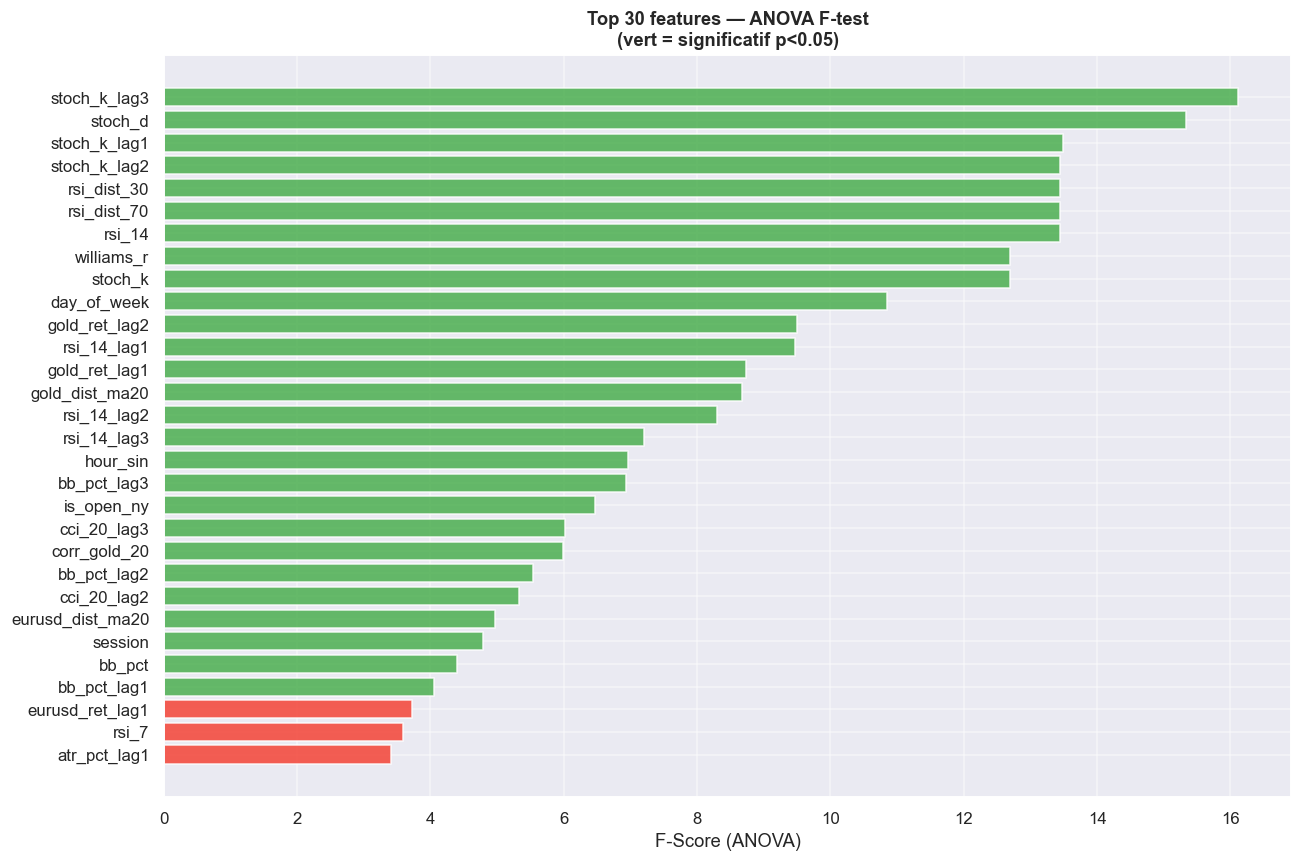

In [14]:
# ── ANOVA F-test ──────────────────────────────────────────────────────────────
f_scores, f_pvalues = f_classif(X_train, y_train)

df_ftest = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'f_score'  : f_scores,
    'f_pvalue' : f_pvalues,
    'significant' : f_pvalues < 0.05
}).sort_values('f_score', ascending=False).reset_index(drop=True)

df_ftest['f_rank'] = df_ftest['f_score'].rank(ascending=False).astype(int)

print(f'=== ANOVA F-test ===')
print(f'  Features significatives (p<0.05) : {df_ftest["significant"].sum()} / {len(df_ftest)}')
print(f'  Features non significatives      : {(~df_ftest["significant"]).sum()}')
print(f'\n  Top 20 features :')
display(df_ftest[['feature','f_score','f_pvalue','significant']].head(20))

# ── Visualisation top 30 ──────────────────────────────────────────────────────
top30_f = df_ftest.head(30)
fig, ax = plt.subplots(figsize=(12, 8))
colors  = ['#4CAF50' if s else '#F44336' for s in top30_f['significant']]
ax.barh(top30_f['feature'][::-1], top30_f['f_score'][::-1],
        color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title('Top 30 features — ANOVA F-test\n(vert = significatif p<0.05)', fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Mutual Information — `mutual_info_classif`

Complément au F-test : capture les **relations non-linéaires** entre features et label.
Utile car certains indicateurs (RSI, Stochastique) ont des relations non-linéaires avec la direction.

> Un F-test nul ne signifie pas forcément qu'une feature est inutile — elle peut avoir un effet non-linéaire.

=== Mutual Information ===
  Features avec MI > 0    : 84 / 106
  Features avec MI = 0    : 22  ← aucune information

  Top 20 features :


,feature,mi_score
0,range_pct,0.009096
1,eurusd_ret_lag3,0.005324
2,brent_ret_lag1,0.005307
3,log_ret_lag1,0.005254
4,roc_10_lag3,0.005071
5,brent_ret_lag3,0.004790
6,corr_eurusd_20,0.004747
7,ret_pct,0.004687
8,atr_pct_lag1,0.004573
9,eurusd_dist_ma20,0.004551


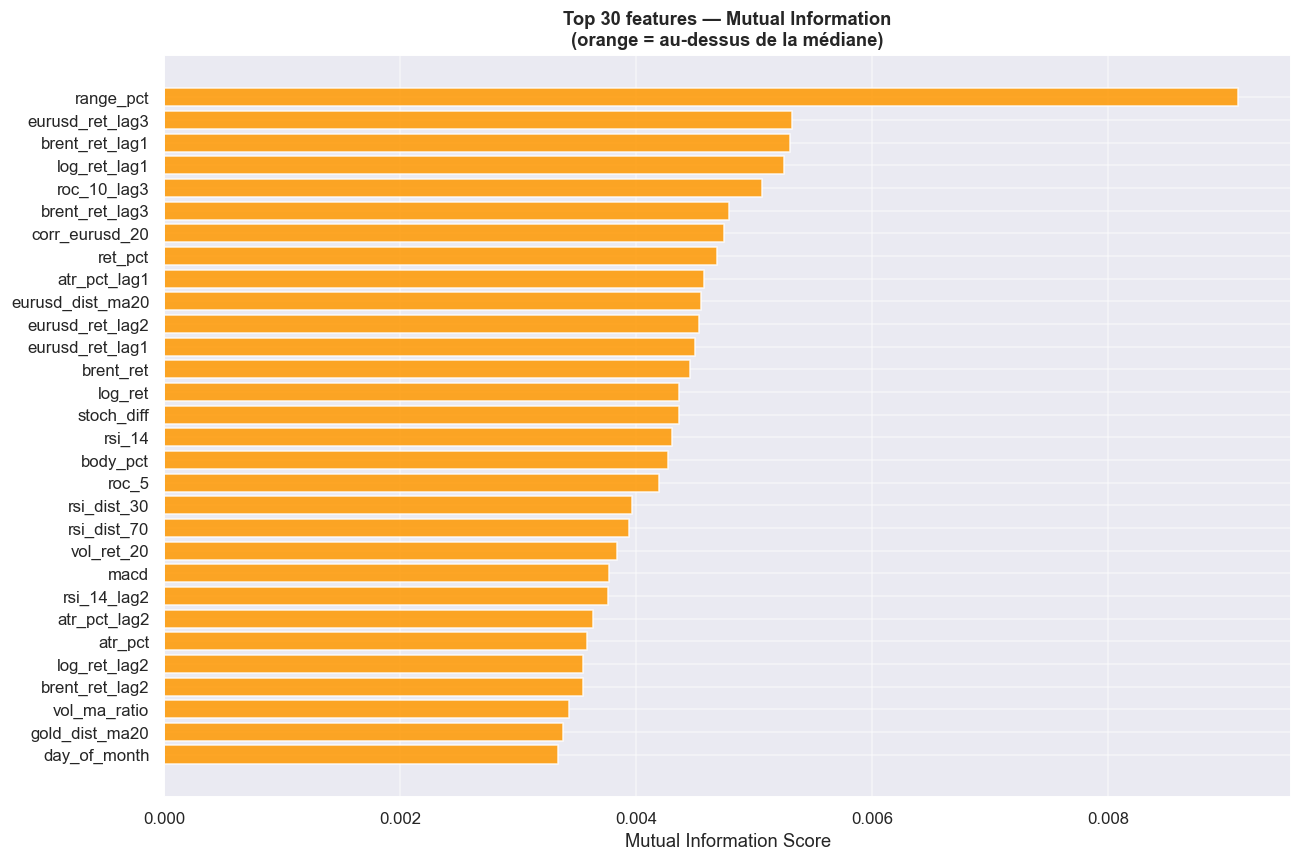

In [3]:
# ── Mutual Information ────────────────────────────────────────────────────────
# random_state pour reproductibilité, n_neighbors=5 (défaut sklearn)
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=5)

df_mi = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'mi_score' : mi_scores,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

df_mi['mi_rank'] = df_mi['mi_score'].rank(ascending=False).astype(int)

print('=== Mutual Information ===')
print(f'  Features avec MI > 0    : {(df_mi["mi_score"] > 0).sum()} / {len(df_mi)}')
print(f'  Features avec MI = 0    : {(df_mi["mi_score"] == 0).sum()}  ← aucune information')
print(f'\n  Top 20 features :')
display(df_mi[['feature','mi_score']].head(20))

# Visualisation top 30
top30_mi = df_mi.head(30)
fig, ax  = plt.subplots(figsize=(12, 8))
colors_mi = ['#FF9800' if v > df_mi['mi_score'].median() else '#9E9E9E'
              for v in top30_mi['mi_score']]
ax.barh(top30_mi['feature'][::-1], top30_mi['mi_score'][::-1],
        color=colors_mi[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 30 features — Mutual Information\n(orange = au-dessus de la médiane)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Corrélation de Pearson avec le label

Référence simple — mesure la **relation linéaire** entre chaque feature et le label.
Complémentaire au F-test (même hypothèse linéaire mais interprétation directe).

=== Corrélation de Pearson (valeur absolue) ===
  |corr| > 0.05 : 0 features
  |corr| > 0.10 : 0 features

  Top 20 :


,feature,pearson,pearson_abs
0,stoch_k_lag3,-0.018042,0.018042
1,stoch_d,-0.017599,0.017599
2,stoch_k_lag1,-0.016511,0.016511
3,stoch_k_lag2,-0.016487,0.016487
4,rsi_14,-0.016481,0.016481
5,rsi_dist_30,-0.016481,0.016481
6,rsi_dist_70,-0.016481,0.016481
7,stoch_k,-0.016018,0.016018
8,williams_r,-0.016018,0.016018
9,day_of_week,-0.014804,0.014804


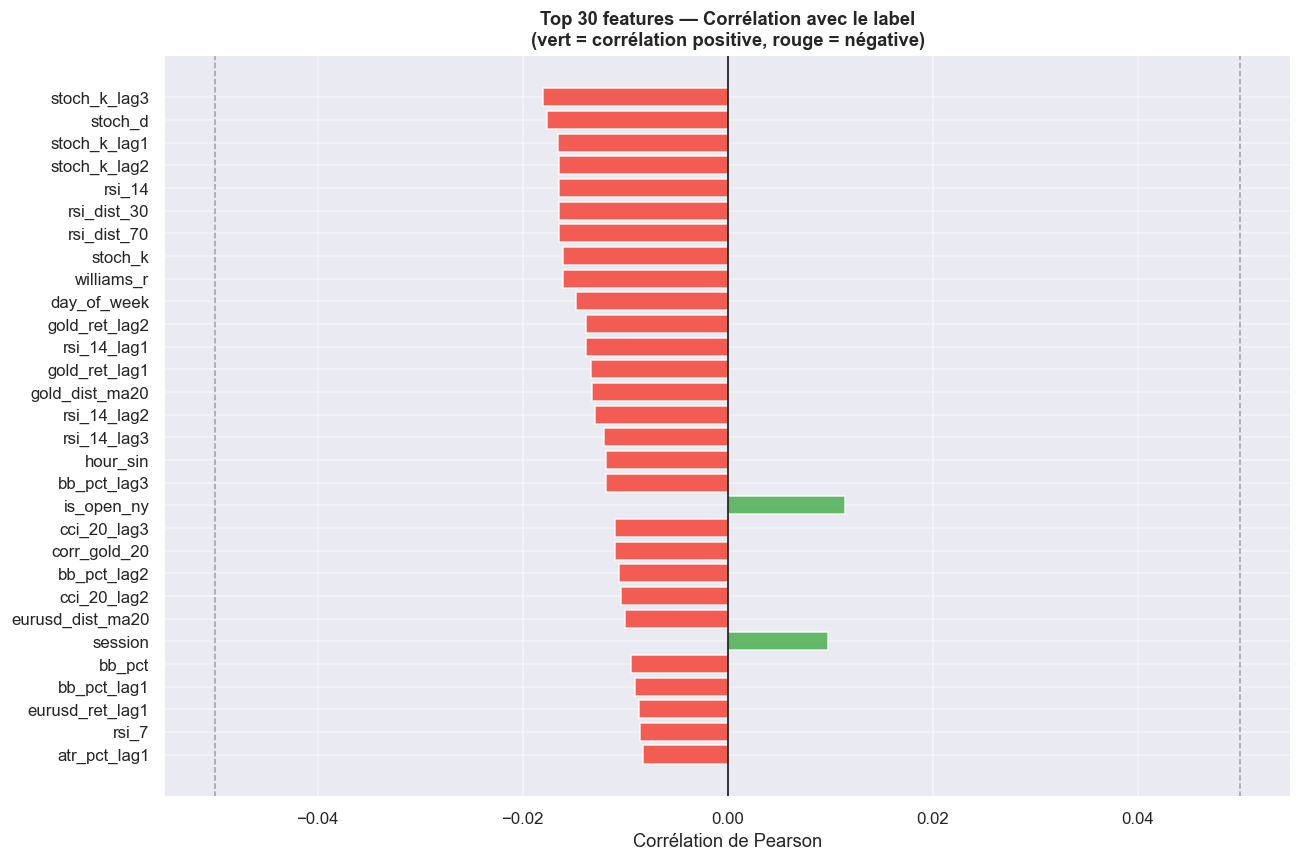

In [4]:
# ── Corrélation de Pearson ────────────────────────────────────────────────────
corr_vals = pd.Series(
    [np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(len(FEATURE_COLS))],
    index=FEATURE_COLS
)

df_corr = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'pearson'    : corr_vals.values,
    'pearson_abs': corr_vals.abs().values,
}).sort_values('pearson_abs', ascending=False).reset_index(drop=True)

df_corr['corr_rank'] = df_corr['pearson_abs'].rank(ascending=False).astype(int)

print('=== Corrélation de Pearson (valeur absolue) ===')
print(f'  |corr| > 0.05 : {(df_corr["pearson_abs"] > 0.05).sum()} features')
print(f'  |corr| > 0.10 : {(df_corr["pearson_abs"] > 0.10).sum()} features')
print(f'\n  Top 20 :')
display(df_corr[['feature','pearson','pearson_abs']].head(20))

# Visualisation
top30_c = df_corr.head(30)
fig, ax = plt.subplots(figsize=(12, 8))
colors_c = ['#4CAF50' if v > 0 else '#F44336' for v in top30_c['pearson']]
ax.barh(top30_c['feature'][::-1], top30_c['pearson'][::-1],
        color=colors_c[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1)
ax.axvline( 0.05, color='gray', lw=1, linestyle='--', alpha=0.7)
ax.axvline(-0.05, color='gray', lw=1, linestyle='--', alpha=0.7)
ax.set_xlabel('Corrélation de Pearson')
ax.set_title('Top 30 features — Corrélation avec le label\n(vert = corrélation positive, rouge = négative)',
             fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Analyse de stabilité temporelle

**Innovation par rapport au mémoire** : une feature peut scorer fort sur l'ensemble du train mais être instable dans le temps — ce qui signifie qu'elle ne généralisera pas bien.

On découpe le train en **4 fenêtres temporelles** et on vérifie si le F-score d'une feature est cohérent sur toutes les fenêtres.

=== Fenêtres temporelles ===
  W1 : 2024-12-11 → 2025-03-20 (12,369 obs)
  W2 : 2025-03-20 → 2025-06-18 (12,369 obs)
  W3 : 2025-06-18 → 2025-10-06 (12,369 obs)
  W4 : 2025-10-06 → 2026-01-19 (12,370 obs)

  Features stables (CV < médiane) : 53 / 106
  Top 15 features les plus stables ET informatives :


,mean_score,std_score,cv,stable
brent_dist_ma20,15.019,9.268,0.617,True
vol_ma_ratio,12.549,13.809,1.100,False
hour_cos,11.107,8.475,0.763,True
vol_ratio_lag1,9.140,9.527,1.042,False
vol_ratio_lag2,8.819,10.073,1.142,False
vol_ratio_lag3,8.080,9.362,1.159,False
vol_surge,7.186,6.722,0.935,True
vol_ratio,7.186,6.722,0.935,True
hour_sin,6.519,4.057,0.622,True
stoch_d,6.395,7.154,1.119,False


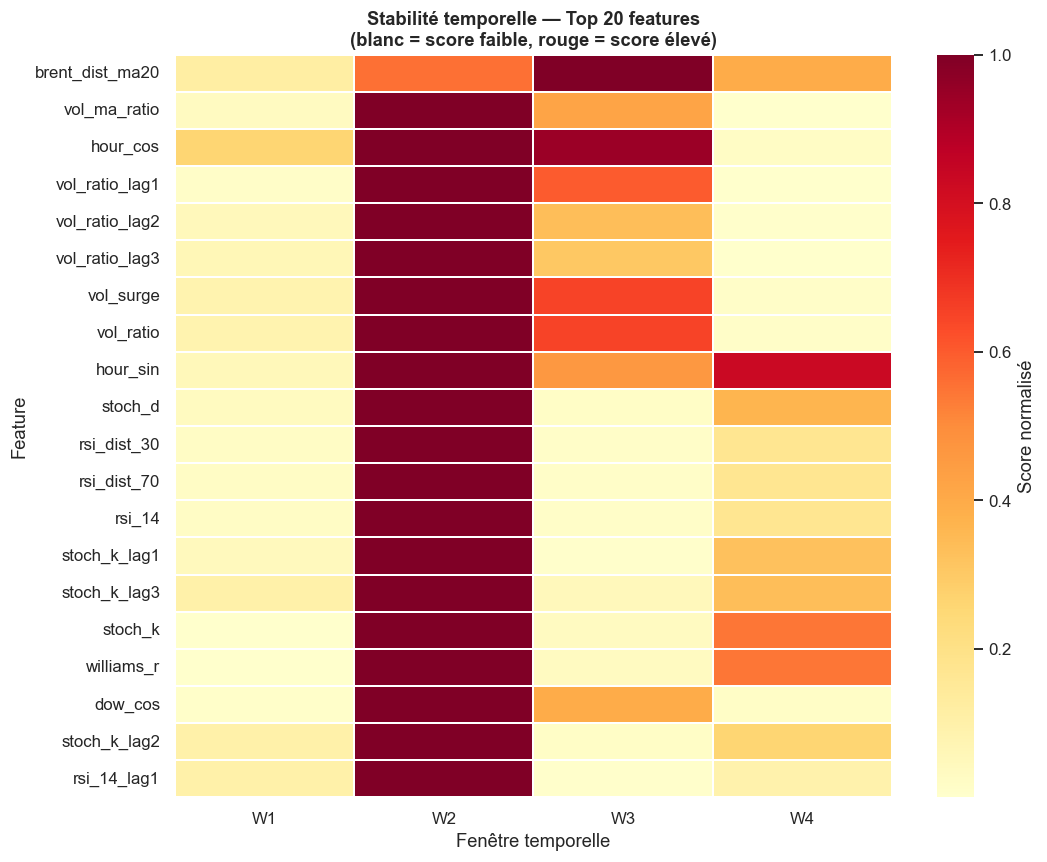

In [5]:
# ── Découpage en 4 fenêtres temporelles ──────────────────────────────────────
n = len(df_train)
windows = [
    df_train.iloc[: n//4],
    df_train.iloc[n//4 : n//2],
    df_train.iloc[n//2 : 3*n//4],
    df_train.iloc[3*n//4 :]
]

print('=== Fenêtres temporelles ===')
for i, w in enumerate(windows):
    print(f'  W{i+1} : {w.index.min().date()} → {w.index.max().date()} ({len(w):,} obs)')

# F-score par fenêtre
stability_scores = {}
for i, w in enumerate(windows):
    Xw = w[FEATURE_COLS].values
    yw = w['label'].values.astype(int)
    fs, _ = f_classif(Xw, yw)
    stability_scores[f'W{i+1}'] = fs

df_stab = pd.DataFrame(stability_scores, index=FEATURE_COLS)

# Coefficient de variation (std/mean) → plus c'est bas, plus c'est stable
df_stab['mean_score'] = df_stab.mean(axis=1)
df_stab['std_score']  = df_stab.std(axis=1)
df_stab['cv']         = df_stab['std_score'] / (df_stab['mean_score'].abs() + 1e-9)
df_stab['stable']     = df_stab['cv'] < df_stab['cv'].median()

df_stab_sorted = df_stab.sort_values('mean_score', ascending=False)

print(f'\n  Features stables (CV < médiane) : {df_stab["stable"].sum()} / {len(df_stab)}')
print(f'  Top 15 features les plus stables ET informatives :')
display(df_stab_sorted[['mean_score','std_score','cv','stable']].head(15).round(3))

# Visualisation : heatmap top 20 features par fenêtre
top20_names = df_stab_sorted.head(20).index.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
heatmap_data = df_stab.loc[top20_names, ['W1','W2','W3','W4']]
# Normalisation par ligne pour comparer les patterns
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1) + 1e-9, axis=0)
sns.heatmap(heatmap_norm, annot=False, cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Score normalisé'})
ax.set_title('Stabilité temporelle — Top 20 features\n(blanc = score faible, rouge = score élevé)',
             fontweight='bold')
ax.set_xlabel('Fenêtre temporelle'); ax.set_ylabel('Feature')
plt.tight_layout(); plt.show()

## 5. Score combiné — Synthèse des 3 méthodes

On combine les 3 approches en normalisant chaque score dans [0,1] puis en calculant une **moyenne pondérée** :

- **F-test (50%)** : méthode principale du mémoire
- **Mutual Information (30%)** : capture le non-linéaire
- **Stabilité (20%)** : robustesse dans le temps

> Cette approche est plus robuste que d'utiliser une seule méthode.

In [6]:
# ── Normalisation [0,1] de chaque score ──────────────────────────────────────
def normalize_01(series):
    mn, mx = series.min(), series.max()
    if mx - mn < 1e-9:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# Construction du DataFrame combiné
df_combined = pd.DataFrame({'feature': FEATURE_COLS})
df_combined = df_combined.set_index('feature')

# Scores normalisés
df_combined['f_norm']      = normalize_01(df_ftest.set_index('feature')['f_score'])
df_combined['mi_norm']     = normalize_01(df_mi.set_index('feature')['mi_score'])
df_combined['stable_norm'] = normalize_01(1 / (df_stab['cv'] + 1e-9))  # inverse du CV

# Score combiné pondéré
df_combined['score_final'] = (
    0.50 * df_combined['f_norm'] +
    0.30 * df_combined['mi_norm'] +
    0.20 * df_combined['stable_norm']
)

# Rangs individuels pour analyse
df_combined['f_rank']    = df_ftest.set_index('feature')['f_rank']
df_combined['mi_rank']   = df_mi.set_index('feature')['mi_rank']
df_combined['p_value']   = df_ftest.set_index('feature')['f_pvalue']
df_combined['significant'] = df_ftest.set_index('feature')['significant']

df_combined = df_combined.sort_values('score_final', ascending=False)
df_combined['rank_final'] = range(1, len(df_combined) + 1)

print('=== Score Combiné (F-test 50% + MI 30% + Stabilité 20%) ===')
print(f'\n  Top 30 features :')
display(df_combined[['score_final','f_norm','mi_norm','stable_norm','p_value','significant']].head(30).round(4))

=== Score Combiné (F-test 50% + MI 30% + Stabilité 20%) ===

  Top 30 features :


,score_final,f_norm,mi_norm,stable_norm,p_value,significant
feature,,,,,,
stoch_k_lag3,0.5830,1.0000,0.2364,0.0604,0.0001,True
rsi_14,0.5640,0.8344,0.4733,0.0238,0.0002,True
rsi_dist_30,0.5527,0.8344,0.4357,0.0238,0.0002,True
rsi_dist_70,0.5519,0.8344,0.4331,0.0238,0.0002,True
eurusd_dist_ma20,0.5044,0.3087,0.5003,1.0000,0.0257,True
stoch_k_lag2,0.4995,0.8349,0.2426,0.0463,0.0002,True
stoch_d,0.4852,0.9515,0.0000,0.0475,0.0001,True
stoch_k_lag1,0.4830,0.8374,0.1858,0.0430,0.0002,True
gold_ret_lag2,0.4461,0.5899,0.3655,0.2071,0.0021,True


## 6. Visualisation comparative des méthodes

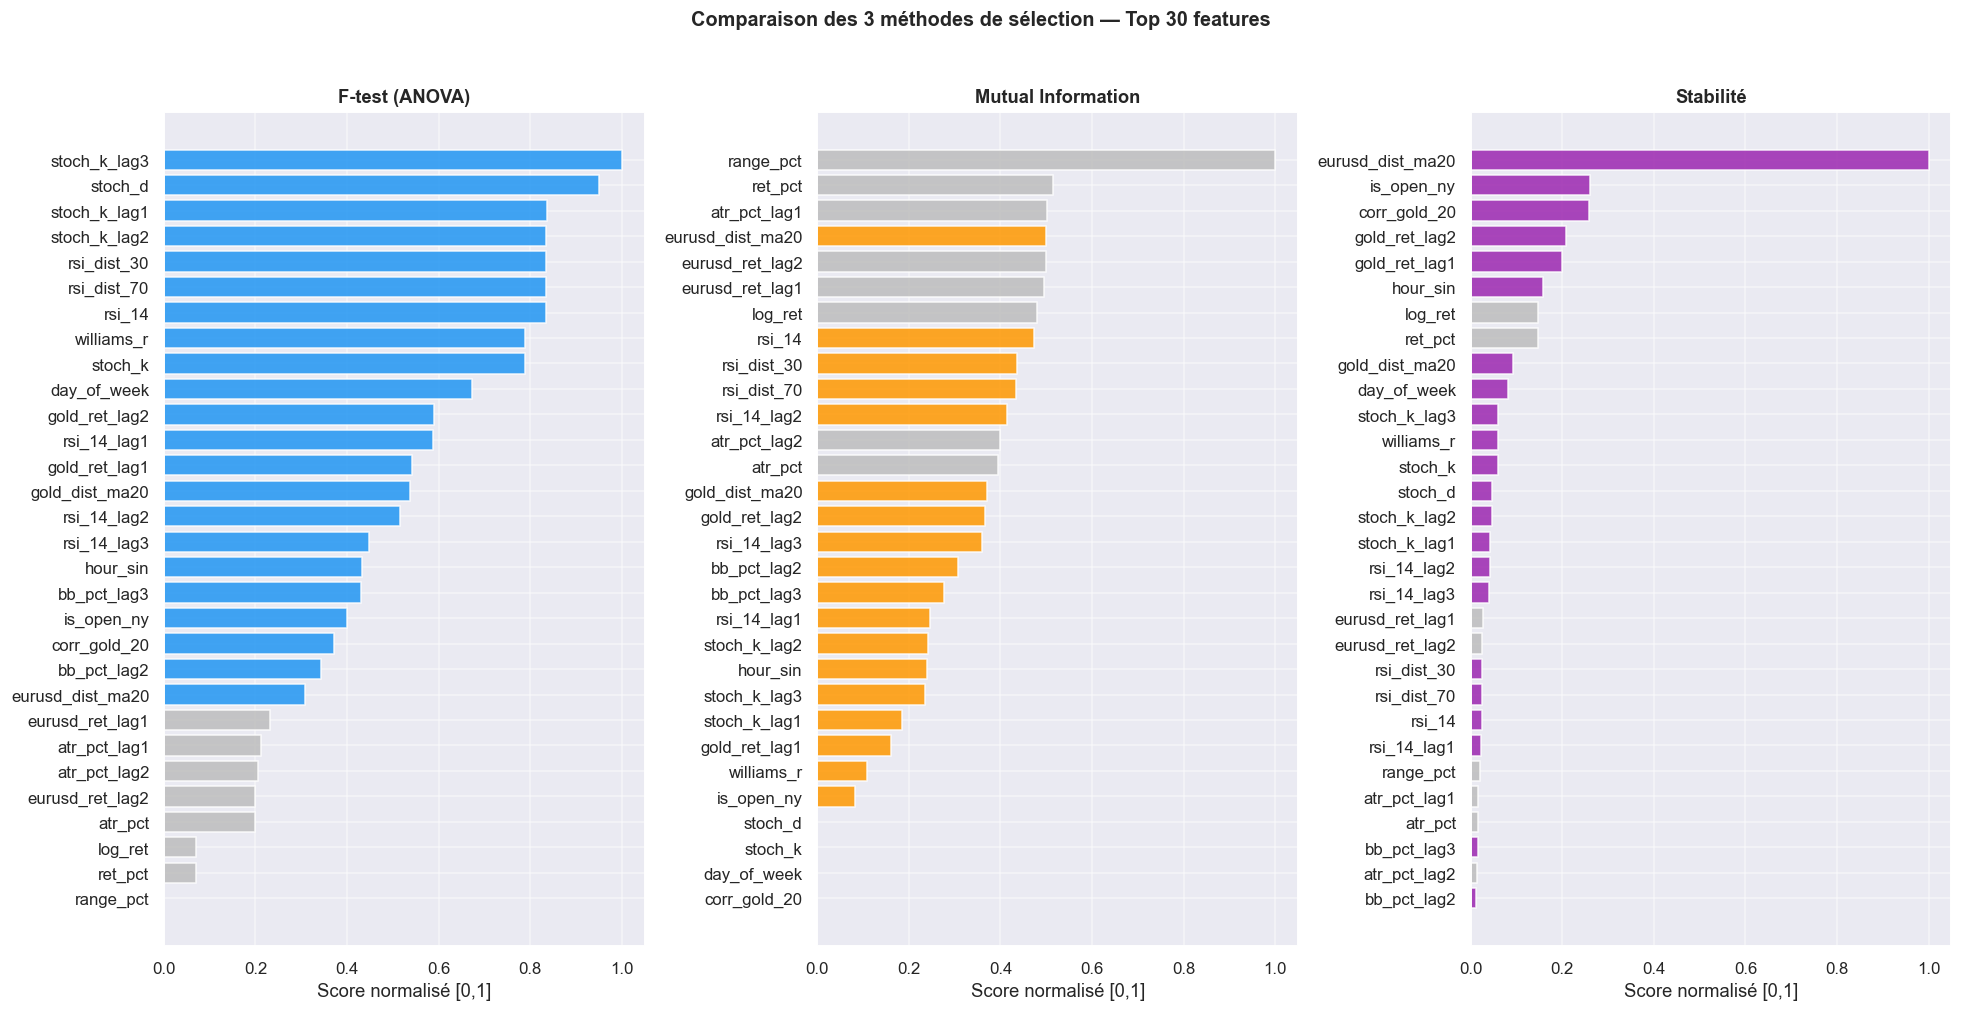

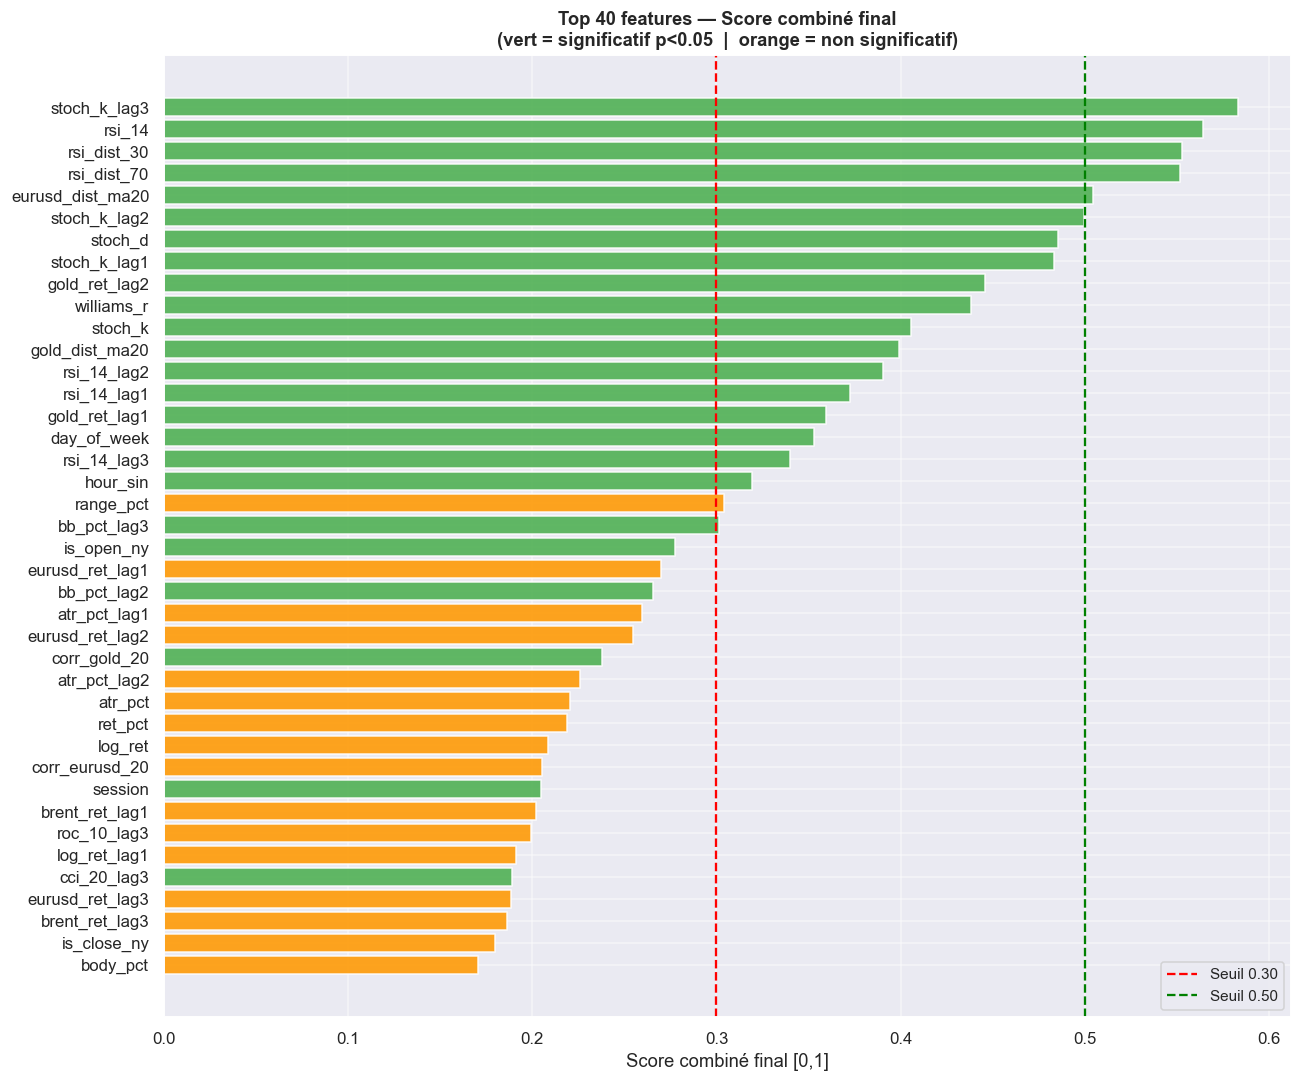

In [7]:
# ── Top 30 score final ────────────────────────────────────────────────────────
top30 = df_combined.head(30).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 9))

for ax, (col, title, color) in zip(axes, [
    ('f_norm',      'F-test (ANOVA)',     '#2196F3'),
    ('mi_norm',     'Mutual Information', '#FF9800'),
    ('stable_norm', 'Stabilité',          '#9C27B0'),
]):
    vals = top30.sort_values(col)[col]
    names = top30.sort_values(col)['feature']
    bar_colors = [color if s else '#BDBDBD'
                  for s in top30.sort_values(col)['significant']]
    ax.barh(names, vals, color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score normalisé [0,1]')
    ax.set_xlim(0, 1.05)

plt.suptitle('Comparaison des 3 méthodes de sélection — Top 30 features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Score final ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
top40   = df_combined.head(40).reset_index()
colors_final = ['#4CAF50' if s else '#FF9800'
                for s in top40['significant']]
ax.barh(top40['feature'][::-1], top40['score_final'][::-1],
        color=colors_final[::-1], edgecolor='white', alpha=0.88)
ax.axvline(0.3, color='red',  lw=1.5, linestyle='--', label='Seuil 0.30')
ax.axvline(0.5, color='green',lw=1.5, linestyle='--', label='Seuil 0.50')
ax.set_xlabel('Score combiné final [0,1]')
ax.set_title('Top 40 features — Score combiné final\n(vert = significatif p<0.05  |  orange = non significatif)',
             fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## 7. Sélection finale — Choix du K optimal

**Comme dans le mémoire** : on teste chaque modèle avec K features croissant (de 5 à 60) et on sélectionne le K optimal. Ici on fait une **analyse préliminaire** pour identifier le bon intervalle.

> *"We design an experiment whereby we attempt each classifier for 70 times on identical datasets, each iteration increasing the number of features"* — Dingli & Sant Fournier

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import accuracy_score

# ── Test de K features croissant (validation croisée temporelle) ──────────────
# TimeSeriesSplit : respecte l'ordre temporel, pas de data leakage
tscv = TimeSeriesSplit(n_splits=5)

K_values  = [5, 8, 10, 12, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 106]
cv_scores = []

print('Test en cours... (peut prendre 1-2 minutes)')
for k in K_values:
    k_eff = min(k, len(FEATURE_COLS))
    # Sélection des top-k features selon score combiné
    top_k_features = df_combined.head(k_eff).index.tolist()
    idx_k = [FEATURE_COLS.index(f) for f in top_k_features]
    Xk = X_train[:, idx_k]

    # Logistic Regression — rapide, comme dans le mémoire
    lr = LogisticRegression(max_iter=200, random_state=42, class_weight='balanced')
    scores = cross_val_score(lr, Xk, y_train, cv=tscv, scoring='accuracy', n_jobs=-1)
    cv_scores.append({
        'k'         : k_eff,
        'mean_acc'  : scores.mean(),
        'std_acc'   : scores.std(),
        'min_acc'   : scores.min(),
        'max_acc'   : scores.max(),
    })
    print(f'  K={k_eff:3d} → acc = {scores.mean():.4f} ± {scores.std():.4f}')

df_kscores = pd.DataFrame(cv_scores)
best_k_row = df_kscores.loc[df_kscores['mean_acc'].idxmax()]
K_OPTIMAL  = int(best_k_row['k'])

print(f'\n✅ K optimal : {K_OPTIMAL} features (acc = {best_k_row["mean_acc"]:.4f})')

Test en cours... (peut prendre 1-2 minutes)
  K=  5 → acc = 0.5041 ± 0.0106
  K=  8 → acc = 0.5036 ± 0.0067
  K= 10 → acc = 0.5068 ± 0.0066
  K= 12 → acc = 0.5021 ± 0.0086
  K= 15 → acc = 0.4995 ± 0.0061
  K= 18 → acc = 0.5031 ± 0.0061
  K= 20 → acc = 0.5049 ± 0.0066
  K= 25 → acc = 0.5069 ± 0.0072
  K= 30 → acc = 0.5073 ± 0.0064
  K= 35 → acc = 0.5034 ± 0.0066
  K= 40 → acc = 0.5047 ± 0.0067
  K= 50 → acc = 0.5029 ± 0.0099
  K= 60 → acc = 0.5022 ± 0.0097
  K= 80 → acc = 0.4996 ± 0.0082
  K=106 → acc = 0.5006 ± 0.0111

✅ K optimal : 30 features (acc = 0.5073)


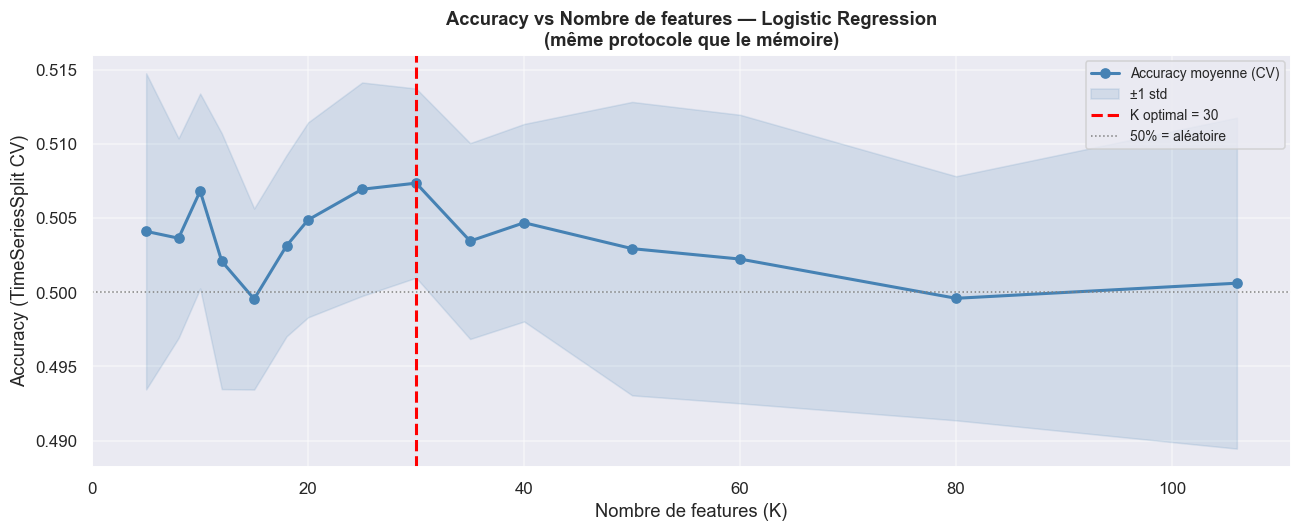


→ Le graphique montre le compromis biais/variance :
  - Trop peu de features → underfitting (accuracy croissante)
  - Trop de features    → overfitting  (accuracy décroissante)
  - K optimal = 30 features


In [9]:
# ── Visualisation accuracy vs K ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_kscores['k'], df_kscores['mean_acc'],
        marker='o', lw=2, color='steelblue', label='Accuracy moyenne (CV)')
ax.fill_between(df_kscores['k'],
                df_kscores['mean_acc'] - df_kscores['std_acc'],
                df_kscores['mean_acc'] + df_kscores['std_acc'],
                alpha=0.15, color='steelblue', label='±1 std')
ax.axvline(K_OPTIMAL, color='red', lw=2, linestyle='--',
           label=f'K optimal = {K_OPTIMAL}')
ax.axhline(0.50, color='gray', lw=1, linestyle=':', label='50% = aléatoire')
ax.set_xlabel('Nombre de features (K)')
ax.set_ylabel('Accuracy (TimeSeriesSplit CV)')
ax.set_title('Accuracy vs Nombre de features — Logistic Regression\n(même protocole que le mémoire)',
             fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print(f'\n→ Le graphique montre le compromis biais/variance :')
print(f'  - Trop peu de features → underfitting (accuracy croissante)')
print(f'  - Trop de features    → overfitting  (accuracy décroissante)')
print(f'  - K optimal = {K_OPTIMAL} features')

## 8. Features sélectionnées — Liste finale

In [10]:
# ── Liste des K_OPTIMAL features retenues ────────────────────────────────────
SELECTED_FEATURES = df_combined.head(K_OPTIMAL).index.tolist()

print(f'=== {K_OPTIMAL} FEATURES SÉLECTIONNÉES ===\n')

# Affichage par catégorie
categories = {
    'Prix de base'  : ['log_ret','ret_pct','body','body_pct','range','range_pct',
                        'close_pct_range','upper_shadow','lower_shadow','vol_ratio'],
    'Tendance'      : ['dist_','ema_cross','macd'],
    'Momentum'      : ['rsi','stoch','williams','roc','momentum','cci'],
    'Volatilité'    : ['atr','bb_width','bb_pct','vol_ret','vol_ratio_5'],
    'Volume'        : ['obv','force','vol_surge','vol_dir','vol_ma'],
    'Temporel'      : ['hour','day','session','sin','cos','is_open','is_close'],
    'Inter-actifs'  : ['gold','brent','eurusd','corr'],
    'Lags'          : ['_lag'],
}

for cat, keywords in categories.items():
    sel = [f for f in SELECTED_FEATURES
           if any(k in f for k in keywords)]
    if sel:
        print(f'  {cat:15s} ({len(sel):2d}) : {", ".join(sel)}')

# Tableau récapitulatif
print(f'\n=== TABLEAU RÉCAPITULATIF ===')
display(df_combined.loc[SELECTED_FEATURES,
    ['score_final','f_norm','mi_norm','stable_norm','p_value','significant']
].round(4))

=== 30 FEATURES SÉLECTIONNÉES ===

  Prix de base    ( 3) : range_pct, ret_pct, log_ret
  Tendance        ( 4) : rsi_dist_30, rsi_dist_70, eurusd_dist_ma20, gold_dist_ma20
  Momentum        (12) : stoch_k_lag3, rsi_14, rsi_dist_30, rsi_dist_70, stoch_k_lag2, stoch_d, stoch_k_lag1, williams_r, stoch_k, rsi_14_lag2, rsi_14_lag1, rsi_14_lag3
  Volatilité      ( 5) : bb_pct_lag3, bb_pct_lag2, atr_pct_lag1, atr_pct_lag2, atr_pct
  Temporel        ( 3) : day_of_week, hour_sin, is_open_ny
  Inter-actifs    ( 7) : eurusd_dist_ma20, gold_ret_lag2, gold_dist_ma20, gold_ret_lag1, eurusd_ret_lag1, eurusd_ret_lag2, corr_gold_20
  Lags            (14) : stoch_k_lag3, stoch_k_lag2, stoch_k_lag1, gold_ret_lag2, rsi_14_lag2, rsi_14_lag1, gold_ret_lag1, rsi_14_lag3, bb_pct_lag3, eurusd_ret_lag1, bb_pct_lag2, atr_pct_lag1, eurusd_ret_lag2, atr_pct_lag2

=== TABLEAU RÉCAPITULATIF ===


,score_final,f_norm,mi_norm,stable_norm,p_value,significant
feature,,,,,,
stoch_k_lag3,0.5830,1.0000,0.2364,0.0604,0.0001,True
rsi_14,0.5640,0.8344,0.4733,0.0238,0.0002,True
rsi_dist_30,0.5527,0.8344,0.4357,0.0238,0.0002,True
rsi_dist_70,0.5519,0.8344,0.4331,0.0238,0.0002,True
eurusd_dist_ma20,0.5044,0.3087,0.5003,1.0000,0.0257,True
stoch_k_lag2,0.4995,0.8349,0.2426,0.0463,0.0002,True
stoch_d,0.4852,0.9515,0.0000,0.0475,0.0001,True
stoch_k_lag1,0.4830,0.8374,0.1858,0.0430,0.0002,True
gold_ret_lag2,0.4461,0.5899,0.3655,0.2071,0.0021,True


## 9. Vérification de la multicolinéarité

Les features très corrélées entre elles apportent une information redondante et peuvent dégrader certains modèles (Logistic Regression notamment). On visualise la matrice de corrélation des features sélectionnées.

⚠️  23 paires avec |corr| > 0.85 :


,feature_1,feature_2,correlation
22,ret_pct,log_ret,1.000
1,rsi_14,rsi_dist_30,1.000
2,rsi_14,rsi_dist_70,1.000
5,rsi_dist_30,rsi_dist_70,1.000
15,williams_r,stoch_k,1.000
20,atr_pct_lag1,atr_pct,0.996
19,atr_pct_lag1,atr_pct_lag2,0.996
21,atr_pct_lag2,atr_pct,0.990
12,stoch_d,stoch_k_lag1,0.960
0,stoch_k_lag3,bb_pct_lag3,0.923


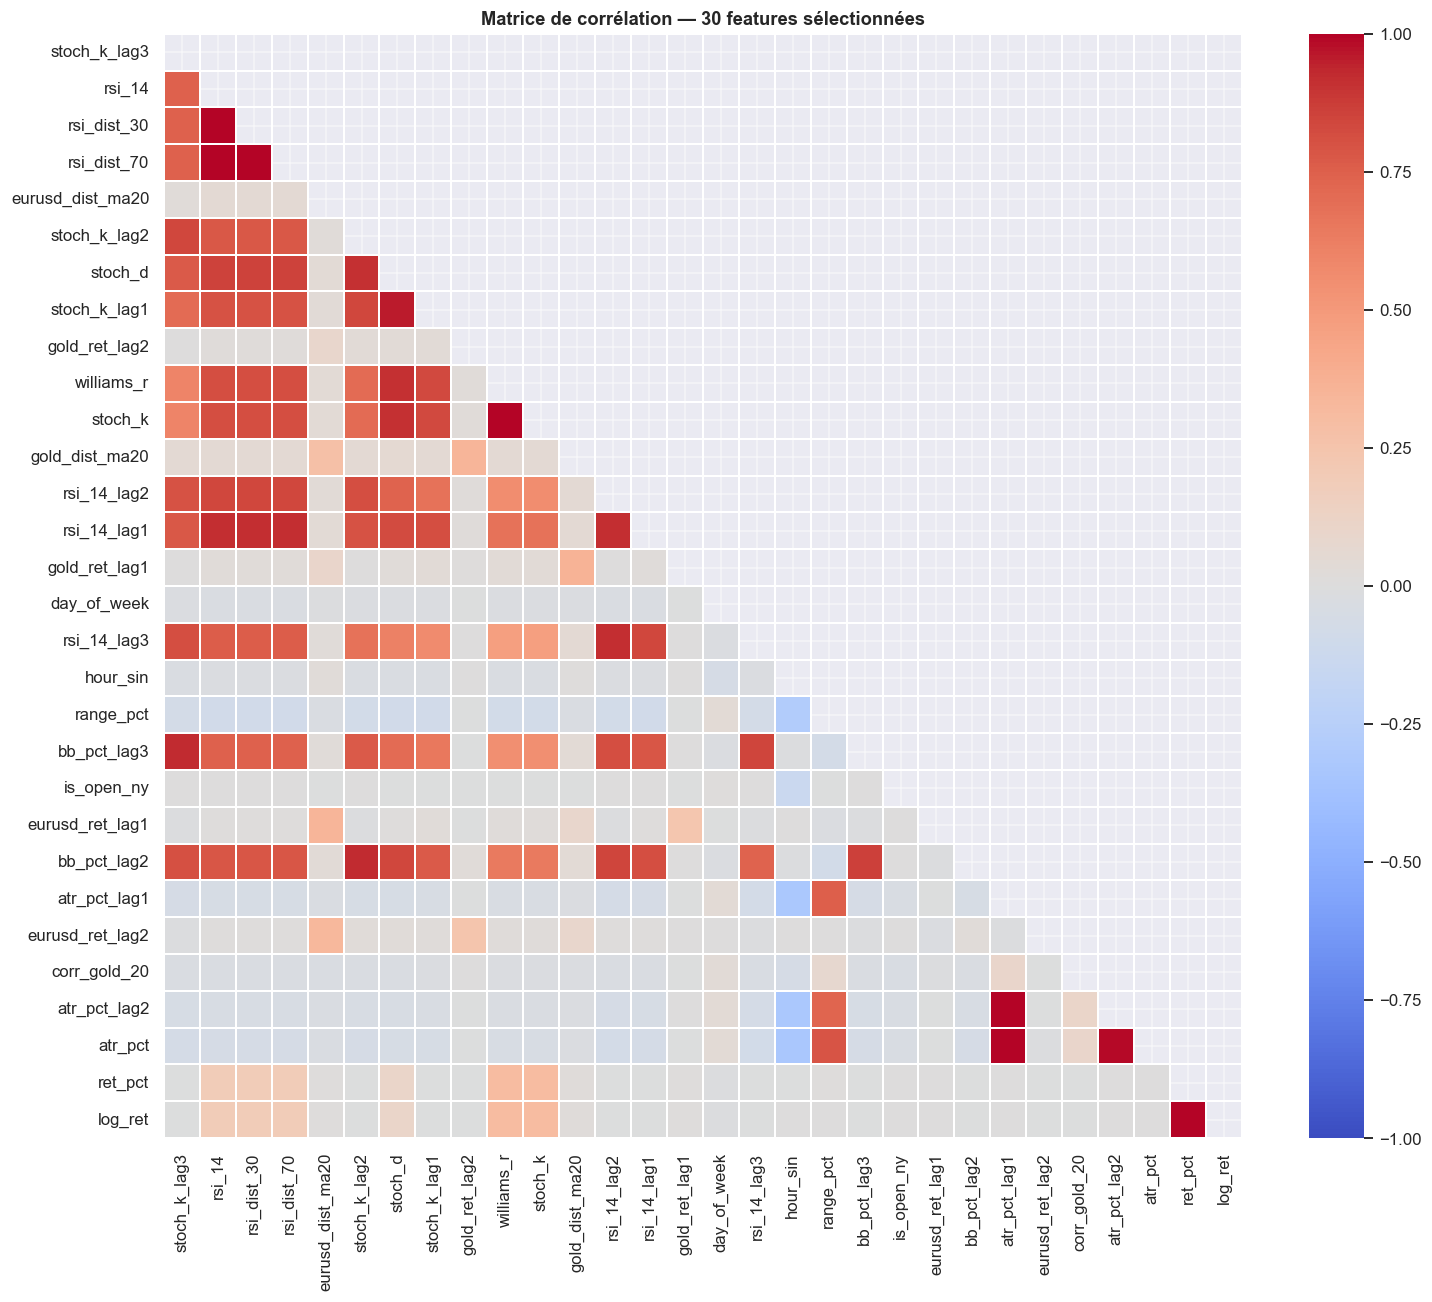

In [11]:
# ── Matrice de corrélation des features sélectionnées ────────────────────────
X_sel = df_train[SELECTED_FEATURES]
corr_matrix = X_sel.corr()

# Paires très corrélées (|r| > 0.85)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(r, 3)
            })

if high_corr:
    df_hc = pd.DataFrame(high_corr).sort_values('correlation', key=abs, ascending=False)
    print(f'⚠️  {len(df_hc)} paires avec |corr| > 0.85 :')
    display(df_hc)
else:
    print('✅ Aucune paire avec |corr| > 0.85')

# Heatmap (si K_OPTIMAL <= 40 pour lisibilité)
if K_OPTIMAL <= 40:
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.2,
                annot=K_OPTIMAL <= 20, fmt='.1f', annot_kws={'size': 7})
    ax.set_title(f'Matrice de corrélation — {K_OPTIMAL} features sélectionnées',
                 fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    # Heatmap top 30 seulement si trop de features
    top30_sel = SELECTED_FEATURES[:30]
    fig, ax = plt.subplots(figsize=(14, 12))
    cm30 = df_train[top30_sel].corr()
    mask = np.triu(np.ones_like(cm30, dtype=bool))
    sns.heatmap(cm30, mask=mask, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.2)
    ax.set_title('Matrice de corrélation — Top 30 features sélectionnées', fontweight='bold')
    plt.tight_layout(); plt.show()

## 10. Export du dataset réduit

In [12]:
# ── Dataset réduit aux features sélectionnées ────────────────────────────────
df_train_sel = df_train[SELECTED_FEATURES + ['label']]
df_test_sel  = df_test[SELECTED_FEATURES  + ['label']]

OUT_DIR = Path('../SCR/data/processed')

df_train_sel.to_csv(OUT_DIR / 'sp500_train_selected.csv')
df_test_sel.to_csv(OUT_DIR  / 'sp500_test_selected.csv')

# Sauvegarde de la liste des features sélectionnées
pd.Series(SELECTED_FEATURES).to_csv(OUT_DIR / 'selected_features.csv',
                                     index=False, header=['feature'])

print('✅ Fichiers exportés :')
print(f'   → sp500_train_selected.csv  ({len(df_train_sel):,} obs × {len(SELECTED_FEATURES)} features)')
print(f'   → sp500_test_selected.csv   ({len(df_test_sel):,} obs × {len(SELECTED_FEATURES)} features)')
print(f'   → selected_features.csv     (liste des {len(SELECTED_FEATURES)} features)')
print(f'\n  Prochaine étape : 04_model_training.ipynb')

✅ Fichiers exportés :
   → sp500_train_selected.csv  (49,477 obs × 30 features)
   → sp500_test_selected.csv   (12,368 obs × 30 features)
   → selected_features.csv     (liste des 30 features)

  Prochaine étape : 04_model_training.ipynb


## 11. Synthèse

In [16]:
print('=' * 55)
print('SYNTHÈSE — FEATURE SELECTION')
print('=' * 55)
print(f'  Features initiales    : {len(FEATURE_COLS)}')
print(f'  Features sélectionnées: {K_OPTIMAL}')
print(f'  Réduction             : {(1 - K_OPTIMAL/len(FEATURE_COLS))*100:.1f}%')
print(f'  Méthode principale    : ANOVA F-test (f_classif) — comme le mémoire')
print(f'  Complément            : Mutual Information + Stabilité temporelle')
print(f'  Validation            : TimeSeriesSplit (5 folds) — pas de data leakage')
print(f'  Accuracy CV (LR)      : {best_k_row["mean_acc"]:.4f} ± {best_k_row["std_acc"]:.4f}')
print()
print('  Top 10 features retenues :')
for i, f in enumerate(SELECTED_FEATURES[:10], 1):
    score = df_combined.loc[f, 'score_final']
    print(f'    {i:2d}. {f:35s} score={score:.4f}')
print()
print('  → Prochaine étape : entraînement des classifieurs (notebook 04)')

SYNTHÈSE — FEATURE SELECTION
  Features initiales    : 106
  Features sélectionnées: 30
  Réduction             : 71.7%
  Méthode principale    : ANOVA F-test (f_classif) — comme le mémoire
  Complément            : Mutual Information + Stabilité temporelle
  Validation            : TimeSeriesSplit (5 folds) — pas de data leakage
  Accuracy CV (LR)      : 0.5073 ± 0.0064

  Top 10 features retenues :
     1. stoch_k_lag3                        score=0.5830
     2. rsi_14                              score=0.5640
     3. rsi_dist_30                         score=0.5527
     4. rsi_dist_70                         score=0.5519
     5. eurusd_dist_ma20                    score=0.5044
     6. stoch_k_lag2                        score=0.4995
     7. stoch_d                             score=0.4852
     8. stoch_k_lag1                        score=0.4830
     9. gold_ret_lag2                       score=0.4461
    10. williams_r                          score=0.4384

  → Prochaine étape : ent